### Importando bibliotecas


In [481]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import Normalizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score



### Criando tabelas

In [ ]:

patients = pd.read_csv('hosp/patients.csv') # 100 pacientes
icu_stays = pd.read_csv('icu/icustays.csv') # Todos os 100 ficaram na UTI
input_events = pd.read_csv('icu/inputevents.csv') # 2 Não receberam medicamentos
procedure_events = pd.read_csv('icu/procedureevents.csv') # 2 Não receberam procedimentos
output_events = pd.read_csv('icu/outputevents.csv')
ingredient_events = pd.read_csv('icu/ingredientevents.csv')
items = pd.read_csv('icu/d_items.csv') # Itens e seus códigos
admissoes = pd.read_csv("hosp/admissions.csv", sep=',')

print("Nº de pacientes:", patients.shape[0])

### Contagem de eventos

#### Vasopressores (unidades de medida bem diferentes, talvez compense mais usar o número total de eventos?)

In [ ]:
vasopressores = ['Vasopressin',
                 'Dopamine',
                 'Epinephrine',
                 'Norepinephrine',
                 'Phenylephrine',
                 'Milrinone',
                 'Dobutamine']


vp = items[items['label'].isin(vasopressores)]

vp = pd.merge(input_events,vp)
vasopres = vp.groupby(['subject_id','stay_id','itemid','label','amountuom'])['itemid'].count().reset_index(name='event_count')
vasopres['stay_total_amount'] = vp.groupby(['subject_id','stay_id','itemid','label','amountuom'])['amount'].sum().values
vasopres['stay_mean'] = vp.groupby(['subject_id','stay_id','itemid','label','amountuom'])['amount'].mean().values
vasopres

#### Contagem de eventos de ventilação (talvez dê pra usar a duração em minutos??)

In [ ]:
ventilacao = ['Mask Ventilation (Intubation)',
              'Non-invasive Ventilation',
              'Invasive Ventilation']

vt = items[items['label'].isin(ventilacao)]
vt = pd.merge(procedure_events,vt)
vent = vt.groupby(['subject_id','stay_id','itemid','label','valueuom'])['itemid'].count().reset_index(name='event_count')
vent['total_duration'] = vt.groupby(['subject_id','stay_id','itemid','label','valueuom'])['value'].sum().values
vent['average_duration'] = vt.groupby(['subject_id','stay_id','itemid','label','valueuom'])['value'].mean().values
vent

#### Contagem de eventos de Terapia de Substituição Renal

In [546]:
tsr_ids = [ 226118,
            227357,
            225725,
            226499,
            224154,
            225810,
            225959,
            227639,
            225183,
            227438,
            224191,
            225806,
            225807,
            228004,
            228005,
            228006,
            224144,
            224145,
            224149,
            224150,
            224151,
            224152,
            224153,
            224404,
            224406,
            226457,
            224135,
            224139,
            224146,
            225323,
            225740,
            225776,
            225951,
            225952,
            225953,
            225954,
            225956,
            225958,
            225961,
            225963,
            225965,
            225976,
            225977,
            227124,
            227290,
            227638,
            227640,
            227753,
            227536,
            227525,
            225441,
            225802,
            225803,
            225805,
            225809,
            225955,
            224270,
            225436
]



vtsr = items[items['itemid'].isin(tsr_ids)]

##### Eventos de entrada (Também tem unidades de medida diferentes)

In [ ]:
vtsri = pd.merge(input_events,vtsr)
tsri = vtsri.groupby(['subject_id','stay_id','itemid','label','amountuom'])['itemid'].count().reset_index(name='count')
tsri['stay_total_amount'] = vtsri.groupby(['subject_id','stay_id','itemid','label','amountuom'])['amount'].sum().values
tsri

##### Eventos de procedimento (unidades diferentes, mas todas são de tempo)

In [ ]:

vtsrp = pd.merge(procedure_events,vtsr)
tsrp = vtsrp.groupby(['subject_id','stay_id','itemid','label','valueuom'])['itemid'].count().reset_index(name='count')
tsrp['stay_total_duration'] = vtsrp.groupby(['subject_id','stay_id','itemid','label','valueuom'])['value'].sum().values


# Corrigindo as medidas de tempo
tsrp.loc[tsrp['valueuom'] == 'day', 'stay_total_duration']  = tsrp[tsrp['valueuom']=='day']['stay_total_duration'] * 1440
tsrp.loc[tsrp['valueuom'] == 'hour', 'stay_total_duration']  = tsrp[tsrp['valueuom']=='hour']['stay_total_duration'] * 60
tsrp['valueuom'] = 'min'
tsrp
#tsrp[tsrp['']]

### Criando tabelona com todos os dados

In [ ]:

tabelona = patients[['subject_id','gender','anchor_age','dod']].copy()


# Vasopressores
for id in tabelona['subject_id'].unique():
    total_count = 0
    for v in vasopres['label'].unique():
        count = vasopres[(vasopres['subject_id'] == id) & (vasopres['label'] == v)]['event_count'].sum()
        tabelona.loc[tabelona['subject_id'] == id, v + '_input_count'] = count
        total_count += count
    tabelona.loc[tabelona['subject_id'] == id, 'vasopressor_input_count'] = total_count

# Ventilação
for id in tabelona['subject_id'].unique():
    total_count = 0
    for v in vent['label'].unique():
        count = 0
        count =  vent[(vent['subject_id'] == id) & (vent['label'] == v)]['total_duration'].sum()
        tabelona.loc[tabelona['subject_id'] == id, v + '_time (min)'] = count
        total_count += count
    tabelona.loc[tabelona['subject_id'] == id, 'ventilation_time (min)'] = total_count

# Procedimentos de tsr
for id in tabelona['subject_id'].unique():
    total_count = 0
    for v in tsrp['label'].unique():
        count = 0
        count =  tsrp[(tsrp['subject_id'] == id) & (tsrp['label'] == v)]['stay_total_duration'].sum()
        tabelona.loc[tabelona['subject_id'] == id, v + '_event_time (min)'] = count
        total_count += count
    tabelona.loc[tabelona['subject_id'] == id, 'tsr_event_time (min)'] = total_count

# Entrada de tsr
for id in tabelona['subject_id'].unique():
    total_count = 0
    for v in tsri['label'].unique():
        count = tsri[(tsri['subject_id'] == id) & (tsri['label'] == v)]['count'].sum()
        tabelona.loc[tabelona['subject_id'] == id, v + '_input_count'] = count
        total_count += count
    tabelona.loc[tabelona['subject_id'] == id, 'tsr_input_count'] = total_count

# Transformando sexo em booleano
tabelona['gender'] = tabelona['gender'] == 'F'

# Determinando as colunas de morte
tabelona['dod'] = pd.to_datetime(tabelona['dod'])
tabelona['death'] = ~tabelona['dod'].isna()

stays = pd.read_csv('icu/icustays.csv')[['outtime','subject_id']]
stays['outtime'] = pd.to_datetime(stays['outtime'])

stays_ultimo = stays.sort_values(by=["subject_id","outtime"],ascending=True)

stays_ultimo = stays_ultimo.groupby("subject_id").last().reset_index()

tabelona = pd.merge(tabelona,stays.groupby('subject_id')['outtime'].max().reset_index(name='last_outtime'))

for id in tabelona['subject_id']:
    tabelona.loc[tabelona['subject_id'] == id, 'icu_death'] = (tabelona[tabelona['subject_id'] ==id]['dod'].notnull()) & (tabelona[tabelona['subject_id'] ==id]['dod'] <= tabelona[tabelona['subject_id'] ==id]['last_outtime'] )


tabelona[['subject_id','anchor_age','gender','death','icu_death','dod','vasopressor_input_count','ventilation_time (min)','tsr_input_count','tsr_event_time (min)']]

mortos2 = tabelona[tabelona["icu_death"]==True]

mortos_id = mortos2["subject_id"].reset_index()

tabelona


### Checando a distribuição dos dados

In [ ]:

vivos = tabelona[tabelona['dod'].isna()]
mortos = tabelona[~tabelona['dod'].isna()]

# VASOPRESSORES
plt.figure(figsize=[5,3])
plt.title("Pacientes vivos")
plt.ylabel("Frequência")
plt.xlabel("Nº de eventos de entrada de vasopressores")
plt.hist(vivos['vasopressor_input_count'],bins=15)
plt.show()
plt.figure(figsize=[5,3])
plt.title("Pacientes falecidos (até 1 ano após ultima alta)")
plt.ylabel("Frequência")
plt.xlabel("Nº de eventos de entrada de vasopressores")
plt.hist(mortos['vasopressor_input_count'],bins=15,color='red')
plt.show()

# VENTILAÇÃO
plt.figure(figsize=[5,3])
plt.title("Pacientes vivos")
plt.ylabel("Frequência")
plt.xlabel("Tempo de ventilação (min)")
plt.hist(vivos['ventilation_time (min)'],bins=15)
plt.show()
plt.figure(figsize=[5,3])
plt.title("Pacientes falecidos (até 1 ano após ultima alta)")
plt.ylabel("Frequência")
plt.xlabel("Tempo de ventilação (min)")
plt.hist(mortos['ventilation_time (min)'],bins=15,color='red')
plt.show()

# ENTRADA DE TSR
plt.figure(figsize=[5,3])
plt.title("Pacientes vivos")
plt.ylabel("Frequência")
plt.xlabel("Nº de eventos de entrada de tsr")
plt.hist(vivos['tsr_input_count'],bins=15)
plt.show()
plt.figure(figsize=[5,3])
plt.title("Pacientes falecidos (até 1 ano após ultima alta)")
plt.ylabel("Frequência")
plt.xlabel("Nº de eventos de entrada de tsr")
plt.hist(mortos['tsr_input_count'],bins=15,color='red')
plt.show()

# PROCEDIMENTOS DE TSR
plt.figure(figsize=[5,3])
plt.title("Pacientes vivos")
plt.ylabel("Frequência")
plt.xlabel("Duração dos procedimentos de TSR (min)")
plt.hist(vivos['tsr_event_time (min)'],bins=15)
plt.show()
plt.figure(figsize=[5,3])
plt.title("Pacientes falecidos (até 1 ano após ultima alta)")
plt.ylabel("Frequência")
plt.xlabel("Duração dos procedimentos de TSR (min)")
plt.hist(mortos['tsr_event_time (min)'],bins=15,color='red')
plt.show()

In [ ]:
plt.scatter(tabelona['vasopressor_input_count'],tabelona['ventilation_time (min)'],c=tabelona['death'],cmap='rainbow')
plt.xlabel("vasopressor_input_count")
plt.ylabel("ventilation_time (min)")
plt.title("Morte x tempo de ventilação x contagem de vasopressores")

### Criação das tabelas de comorbidades (baseado nos concepts, ou seja, os dados são de diagnostico)

In [ ]:
import pandas as pd

# Carregar os dados (substitua pelos caminhos corretos dos arquivos CSV)
diagnoses_icd = pd.read_csv('hosp/diagnoses_icd.csv')
admissions = pd.read_csv('hosp/admissions.csv')

# Criar colunas icd9_code e icd10_code
diagnoses_icd['icd9_code'] = diagnoses_icd.apply(
    lambda row: row['icd_code'] if row['icd_version'] == 9 else None, axis=1
)
diagnoses_icd['icd10_code'] = diagnoses_icd.apply(
    lambda row: row['icd_code'] if row['icd_version'] == 10 else None, axis=1
)

# Função para verificar condições com base nos códigos ICD-9 e ICD-10
def check_condition(df, icd9_codes, icd10_codes, col_name):
    df[col_name] = df.apply(
        lambda row: 1 if (
            (row['icd9_code'] and any(row['icd9_code'].startswith(code) for code in icd9_codes)
            or (row['icd10_code'] and any(row['icd10_code'].startswith(code) for code in icd10_codes)
        ))) else 0, axis=1
    )
    return df

# Juntar as tabelas diagnoses_icd e admissions
merged_df = pd.merge(admissions, diagnoses_icd, on='hadm_id', how='left')

# Listas de códigos ICD-9 e ICD-10 para cada comorbidade
conditions = {
    'myocardial_infarct': {
        'icd9': ['410', '412'],
        'icd10': ['I21', 'I22', 'I252']
    },
    'congestive_heart_failure': {
        'icd9': ['428', '39891', '40201', '40211', '40291', '40401', '40403',
                 '40411', '40413', '40491', '40493', '4254', '4255', '4256',
                 '4257', '4258', '4259'],
        'icd10': ['I43', 'I50', 'I099', 'I110', 'I130', 'I132', 'I255', 'I420',
                  'I425', 'I426', 'I427', 'I428', 'I429', 'P290']
    },
    'Peripheral vascular disease':{
        'icd9' : ['440', '441','0930', '4373', '4471', '5571', '5579', 'V434','4431','4432','4433',
                  '4434','4435','4436','4437','4438','4439',],
        'icd10': ['I70', 'I71','I731', 'I738', 'I739', 'I771', 'I790', 'I792', 'K551', 'K558', 'K559', 'Z958', 'Z959']
    },
    'Cerebrovascular disease' :{
        'icd9':['430','431','432','433','434','435','436','437','438','439','36234','G45', 'G46'],
        'icd10': ['I60','I61','I62','I63','I64','I65','I66','I67','I68','I69','H340']
    },
    'Dementia':{
        'icd9':['290','2941', '3312'],
        'icd10': ['F051', 'G311','F00', 'F01', 'F02', 'F03', 'G30']
    },
    'Chronic pulmonary disease':{
        'icd9':['490','491','492','493','494','495','496','497','498','499','500','501','502','503','504','505','4168'
                , '4169', '5064', '5081', '5088'],
        'icd10':['J40','J41','J42','J43','J44','J45','J46','J47','J60','J61','J62','J63','J64','J65','J66','J67','I278',
                  'I279', 'J684', 'J701', 'J703']
    },
    'Rheumatic disease':{
        'icd9': ['725','4465', '7100', '7101', '7102', '7103', '7104', '7140', '7141', '7142', '7148'],
        'icd10': ['M05', 'M06', 'M32', 'M33', 'M34','M315', 'M351', 'M353', 'M360']
    },
    'Peptic ulcer disease': {
        'icd9': ['531', '532', '533', '534'],
        'icd10': ['K25', 'K26', 'K27', 'K28']
    },
    'Mild liver disease' :{
        'icd9': ['570', '571','0706', '0709', '5733', '5734', '5738', '5739', 'V427','07022', '07023', '07032', '07033', '07044', '07054'],
        'icd10': ['B18', 'K73', 'K74','K700', 'K701', 'K702', 'K703', 'K709', 'K713'
                  , 'K714', 'K715', 'K717', 'K760', 'K762'
                  , 'K763', 'K764', 'K768', 'K769', 'Z944']
    },
    'Diabetes without chronic complication' : {
        'icd9': ['2500', '2501', '2502', '2503', '2508', '2509'],
        'icd10': ['E100', 'E101', 'E106', 'E108', 'E109', 'E110', 'E111' , 'E116' , 'E118' , 'E119' , 'E120' , 'E121' , 'E126' , 'E128' ,
                   'E129' , 'E130' , 'E131' , 'E136' , 'E138' , 'E139' , 'E140' , 'E141', 'E146', 'E148', 'E149']
    },
    'Diabetes with chronic complication': {
        'icd9': ['2504', '2505', '2506', '2507'],
        'icd10' :['E102', 'E103', 'E104', 'E105', 'E107', 'E112', 'E113' , 'E114' , 'E115' , 'E117' , 'E122' , 'E123' , 'E124' , 'E125' ,
                   'E127' , 'E132' , 'E133' , 'E134' , 'E135' , 'E137' , 'E142' , 'E143', 'E144', 'E145', 'E147']
    },
    'Hemiplegia or paraplegia': {
        'icd9': ['342', '343','3341', '3440', '3441', '3442' , '3443', '3444', '3445', '3446', '3449'],
        'icd10': ['G81', 'G82','G041', 'G114', 'G801', 'G802', 'G830' , 'G831' , 'G832' , 'G833' , 'G834' , 'G839']
    },
    'Renal disease' :{
        'icd9': ['582', '585', '586', 'V56','5880', 'V420', 'V451','5830','5831','5832','5833','5834','5835','5836','5837','40301' , '40311' ,
                  '40391' , '40402' , '40403' , '40412' , '40413' , '40492' , '40493'],
        'icd10': ['N18', 'N19','I120', 'I131', 'N032', 'N033', 'N034' , 'N035' , 'N036' , 'N037' , 'N052' , 'N053' , 'N054' , 'N055' , 'N056' ,
                   'N057' , 'N250' , 'Z490' , 'Z491' , 'Z492' , 'Z940' , 'Z992']
    },
    'AIDS/HIV' :{
        'icd9': ['042', '043', '044'],
        'icd10':['B20', 'B21', 'B22', 'B24']
    },
    'Hypertension' : {
        'icd9':  ['4019', '5723'],
        'icd10': ['I2720', 'I272', 'K766', 'I10']
    },
    'Hypoglycemia':{
        'icd9': ['2511'],
        'icd10': ['E11649', 'E162']
    },
    'Hyperglycemia':{
        'icd9': [],
        'icd10': ['E0865', 'E1165']
    }
    ,
    'tabacco':{
        'icd9': ['3051', 'V1582'],
        'icd10': ['Z720']
    }
}

# Aplicar as condições para cada comorbidade
for condition, codes in conditions.items():
    merged_df = check_condition(merged_df, codes['icd9'], codes['icd10'], condition)

# Agrupar por hadm_id e calcular o máximo para cada comorbidade
comorbidities = merged_df.groupby('subject_id_x').agg({
    'myocardial_infarct': 'max',
    'congestive_heart_failure': 'max',
    'Peripheral vascular disease': 'max',
    'Cerebrovascular disease': 'max',
    'Dementia':'max',
    'Chronic pulmonary disease': 'max',
    'Diabetes with chronic complication': 'max',
    'Diabetes without chronic complication': 'max',
    'Rheumatic disease': 'max',
    'Peptic ulcer disease': 'max',
    'Mild liver disease': 'max',
    'Hemiplegia or paraplegia': 'max',
    'AIDS/HIV': 'max',
    'Renal disease': 'max',
    'Hypertension': 'max',
    'Hypoglycemia': 'max',
    'Hyperglycemia': 'max',
    'tabacco': 'max',
}).reset_index().rename(columns={"subject_id_x":"subject_id"})


colunas_comorbidades = [
    'myocardial_infarct', 'congestive_heart_failure', 'Peripheral vascular disease',
    'Cerebrovascular disease', 'Dementia', 'Chronic pulmonary disease',
    'Diabetes with chronic complication', 'Diabetes without chronic complication',
    'Rheumatic disease', 'Peptic ulcer disease', 'Mild liver disease',
    'Hemiplegia or paraplegia', 'AIDS/HIV', 'Hypertension', 'Hypoglycemia',
    'Hyperglycemia', 'tabacco'
]

tabelona = pd.merge(tabelona,comorbidities)
tabelona['total_comorbidities']  = tabelona[colunas_comorbidades].sum(axis=1)

tabelona


### Testando a significância da proporção de infarto miocárdico nos mortos

In [ ]:

n_mortos = tabelona['icu_death'].sum()
stat = tabelona[tabelona['icu_death']==1]['myocardial_infarct'].sum()/n_mortos # A proporção observada


n = 10000
proportions = []
for i in range(n):
    # 12 "mortos simulados" são selecionados COM reposição, para assumir que a distribuição reflete a da população
    sample = tabelona.sample(n=n_mortos, replace=True)
    proportions.append(sample['myocardial_infarct'].sum()/n_mortos)


# P valor: Qual a porcentagem de situações simuladas aleatórias tão extremas quanto a observada?
pv = np.sum(np.array(proportions)>=stat)/n

plt.hist(proportions)
plt.axvline(x=stat,color='red',label='Proporção observada entre que morreram na UTI')
plt.xlabel("Proporção")
plt.ylabel("Frequência")
plt.legend()
plt.title("Bootstrap da proporção de infarto miocárdico")
print("Proporção observada na população inteira",tabelona['myocardial_infarct'].sum()/100)
print("Proporção observada entre os mortos:",stat)
print("P valor =",pv)


*É ESTATISTICAMENTE SIGNIFICATIVO*, P-valor: ~3% !!!!

### Testando a significância da diferença na quantidade mediana de comorbidades

In [ ]:

dif_medians = tabelona[tabelona['icu_death']==1]['total_comorbidities'].median() - tabelona[tabelona['icu_death']==0]['total_comorbidities'].median()

# Cópia da tabela pra não afetar os dados da original
test_table = tabelona.copy()

n = 10000
mdiffs = []
for i in range(n):
    # Fazendo o teste da permutação, embaralhando os rótulos de morte.
    deaths = test_table['icu_death'].to_numpy()
    np.random.shuffle(deaths)
    test_table['icu_death'] = deaths


    mdiffs.append(test_table[test_table['icu_death']==1]['total_comorbidities'].median() - test_table[test_table['icu_death']==0]['total_comorbidities'].median())

# P valor: Qual a porcentagem de situações simuladas aleatórias tão extremas quanto a observada?
pv = np.sum(np.array(mdiffs)>=dif_medians)/n

plt.hist(mdiffs)
plt.axvline(x=dif_medians,color='red',label='Diferença das medianas observada (nº de comorbidades)')
plt.title("Teste da permutação na diferença das medianas (nº de comorbidades)")
plt.legend()
print("P valor =",pv)

Não é estatisticamente significativo, P-valor: ~35%

##### Testando de cada comorbidade

In [ ]:
n = 10000
n_mortos = tabelona['icu_death'].sum()

for collumn in colunas_comorbidades:


    stat = tabelona[tabelona['icu_death']==1][collumn].sum()/n_mortos # A proporção observada

    proportions = []
    for i in range(n):
        # 12 "mortos simulados" são selecionados COM reposição, para assumir que a distribuição reflete a da população
        sample = tabelona.sample(n=n_mortos, replace=True)
        proportions.append(sample[collumn].sum()/n_mortos)


    # P valor: Qual a porcentagem de situações simuladas aleatórias tão extremas quanto a observada?
    pv = np.sum(np.array(proportions)>=stat)/n

    #plt.hist(proportions)
    #plt.axvline(x=stat,color='red',label='Proporção (Diabetes without chronic complication) observada')
    #plt.legend()
    #plt.title("Bootstrap da proporção de diabetes sem complicação")
    print("P valor ("+collumn+") =",pv)

### Visualizações

In [ ]:
sns.pairplot(tabelona[['anchor_age','gender','vasopressor_input_count','ventilation_time (min)','tsr_input_count','tsr_event_time (min)','total_comorbidities','myocardial_infarct','icu_death']],hue='icu_death',plot_kws={'alpha': 0.2},diag_kind="hist")

In [ ]:
comobirdade_sum = comorbidities.iloc[:,2:].sum()

plt.figure()

plt.subplot(111)
plt.bar(comobirdade_sum.index,comobirdade_sum.values)
plt.xlabel("Comorbidade")
plt.ylabel("Quantidade")
plt.title("Comorbidade por grupo")
plt.grid(axis='y')

plt.xticks(rotation=45, ha='right')

# Exibir o gráfico
plt.tight_layout()  # Ajusta o layout para evitar cortes
plt.show()



mortos = pd.merge(comorbidities,mortos_id,left_on='subject_id',right_on='subject_id',how='inner')

vivos = comorbidities[~comorbidities['subject_id'].isin(mortos['subject_id'])]



# Filtra as colunas de comorbidades e soma os valores
mortos_sum = mortos[colunas_comorbidades].sum()
mortos_sum1 = mortos[colunas_comorbidades].sum(axis=1)

max_comorbidades_por_paciente = mortos_sum1.max()

contagem_mortos_por_comorbidades = mortos_sum1.value_counts().sort_index()

vivos_sum = vivos[colunas_comorbidades].sum()


plt.figure()
plt.subplot(111)
plt.bar(mortos_sum.index, mortos_sum.values)
plt.xlabel("Comorbidade")
plt.ylabel("Mortos")
plt.title("Tipo de Comorbidade - Mortos")
plt.grid(axis='y')

plt.xticks(rotation=45,ha='right')

plt.tight_layout()
plt.show()

plt.figure()
plt.subplot(111)
plt.bar(contagem_mortos_por_comorbidades.index, contagem_mortos_por_comorbidades.values)
plt.xlabel("Comorbidade")
plt.ylabel("Mortos")
plt.title("Numero de Comorbidade - Mortos")
plt.grid(axis='y')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

plt.figure()
plt.subplot(111)
plt.bar(vivos_sum.index, vivos_sum.values)
plt.xlabel("Comorbidade")
plt.ylabel("Vivos")
plt.title("Tipo de Comorbidade - Vivos")
plt.grid(axis='y')

plt.xticks(rotation=45,ha='right')

plt.tight_layout()
plt.show()

mortos_idade = pd.merge(tabelona, mortos)

# Dicionário para armazenar as médias de idade por comorbidade
medias_por_comorbidade = {}

# Calcular a média de idade para cada comorbidade
for comorbidade in colunas_comorbidades:
    media_idade = mortos_idade[mortos_idade[comorbidade] == 1]['anchor_age'].mean()
    medias_por_comorbidade[comorbidade] = media_idade

# Converter o dicionário em um DataFrame para facilitar a plotagem
df_medias = pd.DataFrame(list(medias_por_comorbidade.items()), columns=['Comorbidade', 'Idade Média'])

# Plotagem do gráfico de barras
plt.figure()
bars = plt.bar(df_medias['Comorbidade'], df_medias['Idade Média'], color='skyblue')
plt.xlabel("Comorbidade")
plt.ylabel("Idade média")
plt.title("Idade média dos mortos por comorbidade")
plt.grid(axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Posição x do texto (centro da barra)
        height + 0.5,  # Posição y do texto (ligeiramente acima da barra)
        f'{height:.1f}',  # Valor formatado com 1 casa decimal
        ha='center',  # Alinhamento horizontal centralizado
        va='bottom',  # Alinhamento vertical na base
        fontsize=10
    )
# Rotação dos rótulos do eixo x para melhor visualização
plt.xticks(rotation=45, ha='right')

# Ajuste do layout para evitar cortes nos rótulos
plt.tight_layout()

# Exibir o gráfico
plt.show()




In [ ]:
mortos_total = pd.merge(tabelona,mortos)

tempo_por_comorbidade = pd.DataFrame(columns=['Comorbidade', 'Tempo_Ventilacao'])

# Itera sobre cada comorbidade e calcula o tempo total de ventilação mecânica
for comorbidade in colunas_comorbidades:
    tempo_total = mortos_total[mortos_total[comorbidade] == 1]['ventilation_time (min)'].sum()
    novo_dado = pd.DataFrame({
        'Comorbidade': [comorbidade],
        'Tempo_Ventilacao': [tempo_total]
    })
    tempo_por_comorbidade = pd.concat([tempo_por_comorbidade, novo_dado], ignore_index=True)

# Cria o gráfico de barras
plt.figure(figsize=(16, 10))
plt.bar(tempo_por_comorbidade['Comorbidade'], tempo_por_comorbidade['Tempo_Ventilacao'])
plt.xlabel("Comorbidade")
plt.ylabel("Tempo Total de Ventilação Mecânica (min)")
plt.title("Tempo de Ventilação Mecânica por Comorbidade")
plt.grid(axis='y')

# Rotaciona os rótulos do eixo x para melhor visualização
plt.xticks(rotation=45, ha='right')

# Ajusta o layout e exibe o gráfico
plt.tight_layout()
plt.show()


dose_por_comorbidade = pd.DataFrame(columns=['Comorbidade', 'qtd_vasopressor'])

# Itera sobre cada comorbidade e calcula o tempo total de ventilação mecânica
for comorbidade in colunas_comorbidades:
    qtd_total = mortos_total[mortos_total[comorbidade] == 1]['vasopressor_input_count'].sum()
    novo_dado = pd.DataFrame({
        'Comorbidade': [comorbidade],
        'qtd_vasopressor': [qtd_total]
    })
    dose_por_comorbidade = pd.concat([dose_por_comorbidade, novo_dado], ignore_index=True)


# Cria o gráfico de barras
plt.figure(figsize=(16, 10))
plt.bar(dose_por_comorbidade['Comorbidade'], dose_por_comorbidade['qtd_vasopressor'])
plt.xlabel("Comorbidade")
plt.ylabel("Quantidade de vasopressores (un)")
plt.title("Quantidade de vasopressores por Comorbidade")
plt.grid(axis='y')

# Rotaciona os rótulos do eixo x para melhor visualização
plt.xticks(rotation=45, ha='right')

# Ajusta o layout e exibe o gráfico
plt.tight_layout()
plt.show()



Tratamento de mortos pós hospital

In [ ]:
pt = patients[["subject_id","anchor_age","dod"]]
pacientes_completo = pd.merge(pt,admissoes,on="subject_id",how="inner")

pacientes_completo = pacientes_completo[["subject_id","anchor_age","hadm_id","admittime","dischtime","dod"]]

pacientes_completo #todas as consultas dos pacientes

pacientes_ultimo = pacientes_completo.sort_values(by=["subject_id","dischtime"],ascending=True)

pacientes_ultimo = pacientes_ultimo.groupby("subject_id").last().reset_index()

#print(pacientes_ultimo.to_string()) #ultimas consultas dos pacientes

mortos_hospital = pacientes_ultimo[~pacientes_ultimo['subject_id'].isin(mortos_id['subject_id'])].reset_index(drop=True)

mortos_in_hospital = mortos_hospital[mortos_hospital['dod']<= mortos_hospital['dischtime']].reset_index(drop=True)

print("Mortos durante a internação no Hospital (Fora da ICU)")
print(mortos_in_hospital.to_string())

mortos_um_ano = mortos_hospital[~mortos_hospital['subject_id'].isin(mortos_in_hospital['subject_id'])].reset_index(drop=True)

#print(mortos_um_ano)

mortos_um_ano['dod'] = pd.to_datetime(mortos_um_ano['dod'])
mortos_um_ano['dischtime'] = pd.to_datetime(mortos_um_ano['dischtime'])

mortos_in_ano = mortos_um_ano[(mortos_um_ano['dod'] - mortos_um_ano['dischtime']).dt.days<=365].reset_index(drop=True)

print("\nMortos em até um ano após última admissão no Hospital")
print(mortos_in_ano)


### Teste de perceptron

/tmp/ipykernel_1810/82543606.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  teste["gender"] = teste["gender"].replace({"M": 1, "F": 0})


Train Accuracy: 0.5043504459703746
Test Accuracy: 0.9655707381108658
F1-score: 0.1238

Falsos Positivos (FP): 158
Falsos Negativos (FN): 2150
Verdadeiros Positivos (VP): 163
Verdadeiros Negativos (VN): 64565

              precision    recall  f1-score   support

  Sobreviveu       0.97      1.00      0.98     64723
       Óbito       0.51      0.07      0.12      2313

    accuracy                           0.97     67036
   macro avg       0.74      0.53      0.55     67036
weighted avg       0.95      0.97      0.95     67036



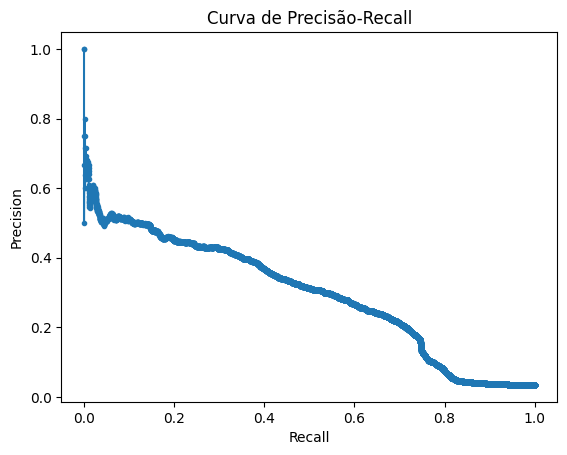

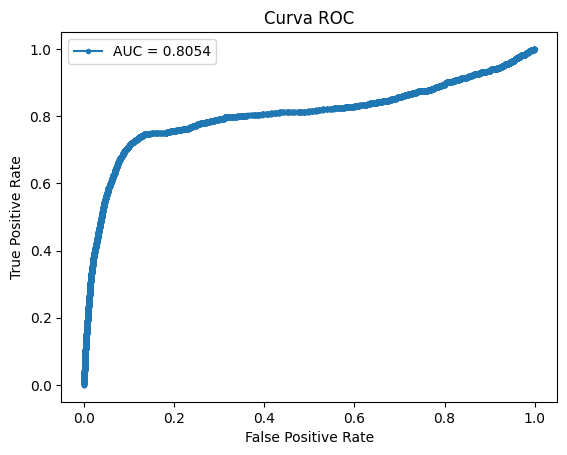

In [545]:
from sklearn.metrics import precision_recall_curve

teste = pd.read_csv("tabela_completa.csv",sep=',').copy()

columns_to_check = ["anchor_age","gender","total_vasopressor_input_count","myocardial_infarct","total_comorbidities","total_ventilation_minutes"]

teste["gender"] = teste["gender"].replace({"M": 1, "F": 0})

teste["icu_death"] = teste["icu_death"].replace({"True": 1, "False" : 0})

# Drop rows where ANY of the specified columns have NaN
teste = teste.dropna(subset=columns_to_check)

t_x = teste[["anchor_age","gender","total_vasopressor_input_count","myocardial_infarct","total_comorbidities","total_ventilation_minutes"]]


t_y = teste["icu_death"]

tx_train, tx_test, ty_train, ty_test = train_test_split(
    t_x, t_y, 
    test_size=0.30, 
    stratify=t_y,
    random_state=1
)


# 1. Normalização obrigatória
scaler = StandardScaler()

# If you need to scale new data with the same scaler:
t_xscaled = scaler.fit_transform(tx_train)

tx_test_t = scaler.transform(tx_test)

clf = MLPClassifier(
    hidden_layer_sizes=(10,5),
    max_iter=2000,
    alpha=0.0008,
    solver='adam',
    activation='relu',
    random_state=1,
    #verbose=True,
    learning_rate_init=0.008,
    #warm_start=True,
    learning_rate='adaptive',
    n_iter_no_change=30,
    early_stopping=True,  # Parada antecipada se o modelo parar de melhorar

)

from sklearn.utils import resample

# Separar as classes
tx_majority = tx_train[ty_train == 0]
ty_majority = ty_train[ty_train == 0]

tx_minority = tx_train[ty_train == 1]
ty_minority = ty_train[ty_train == 1]

# Aumentar a classe minoritária
tx_minority_upsampled, ty_minority_upsampled = resample(
    tx_minority, ty_minority, 
    n_samples=len(ty_majority),  # Igualar ao número de amostras da classe majoritária
    random_state=1
)

# Concatenar os conjuntos balanceados
tx_train_bal = np.vstack((tx_majority, tx_minority_upsampled))
ty_train_bal = np.hstack((ty_majority, ty_minority_upsampled))

t_xscaled_bal = scaler.fit_transform(tx_train_bal)

# Treinar o modelo
clf.fit(tx_train_bal, ty_train_bal)


# 3. Treinamento
#clf.fit(t_xscaled, ty_train)

# 4. Avaliação
y_pred = clf.predict(tx_test_t)

ty_pred = clf.predict(t_xscaled_bal)

# 5. Evaluation
print("Train Accuracy:", accuracy_score(ty_train_bal, ty_pred))
print("Test Accuracy:", accuracy_score(ty_test, y_pred))


# Calcular F1-score
f1 = f1_score(ty_test, y_pred)
print(f"F1-score: {f1:.4f}")

# Matriz de Confusão
tn, fp, fn, tp = confusion_matrix(ty_test, y_pred).ravel()
print(f"""
Falsos Positivos (FP): {fp}
Falsos Negativos (FN): {fn}
Verdadeiros Positivos (VP): {tp}
Verdadeiros Negativos (VN): {tn}
""")

# Relatório Completo
print(classification_report(ty_test, y_pred, target_names=["Sobreviveu", "Óbito"]))

probs = clf.predict_proba(tx_test_t)[:, 1]
precision, recall, _ = precision_recall_curve(ty_test, probs)

plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva de Precisão-Recall')
plt.show()

from sklearn.metrics import roc_curve, roc_auc_score

probs = clf.predict_proba(tx_test_t)[:, 1]
fpr, tpr, _ = roc_curve(ty_test, probs)
roc_auc = roc_auc_score(ty_test, probs)

plt.plot(fpr, tpr, marker='.', label=f'AUC = {roc_auc:.4f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()


#f1_scores = cross_val_score(clf, t_xscaled, ty_pred, cv=5, scoring='f1')
#print(f"F1-score médio (validação cruzada): {f1_scores.mean():.4f}")



/tmp/ipykernel_1810/960746654.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  teste["gender"] = teste["gender"].replace({"M": 1, "F": 0})


Custom Threshold Metrics:
Precision: 0.60
Recall: 0.62

=== Probability Analysis ===
Average death probability (Train): 37.54%
Average death probability (Test): 37.33%
12.7% of patients in critical zone


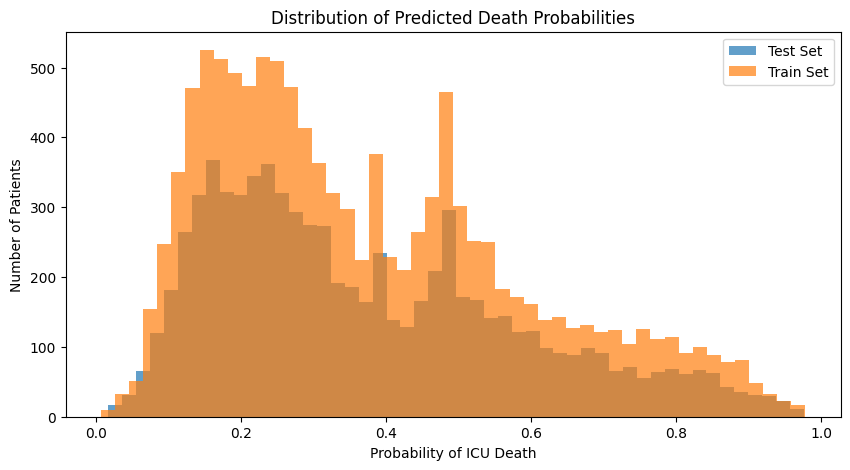


Optimized Threshold: 0.9758
Optimized Test F1: 0.0006966213862765587
Train Accuracy: 0.725854513584575
Test Accuracy: 0.716313921388195
F1-score: 0.5714

Falsos Positivos (FP): 635
Falsos Negativos (FN): 1523
Verdadeiros Positivos (VP): 1347
Verdadeiros Negativos (VN): 4102

              precision    recall  f1-score   support

  Sobreviveu       0.73      0.87      0.79      4737
       Óbito       0.68      0.47      0.56      2870

    accuracy                           0.72      7607
   macro avg       0.70      0.67      0.67      7607
weighted avg       0.71      0.72      0.70      7607



In [510]:
teste = pd.read_csv("tabela_quase_completa.csv",sep=',').copy()

columns_to_check = ["anchor_age","gender","total_vasopressor_input_count","myocardial_infarct","total_comorbidities","total_ventilation_minutes"]

teste["gender"] = teste["gender"].replace({"M": 1, "F": 0})

teste["icu_death"] = teste["icu_death"].replace({"True": 1, "False" : 0})

# Drop rows where ANY of the specified columns have NaN
teste = teste.dropna()

t_x = teste[["anchor_age","gender","total_vasopressor_input_count","myocardial_infarct","total_comorbidities","total_ventilation_minutes"]]


t_y = teste["icu_death"]

tx_train, tx_test, ty_train, ty_test = train_test_split(
    t_x, t_y, 
    test_size=0.40, 
    stratify=t_y,
    random_state=1
)


# 1. Normalização obrigatória
scaler = StandardScaler()

# If you need to scale new data with the same scaler:
t_xscaled = scaler.fit_transform(tx_train)
tx_test_scaled = scaler.transform(tx_test)

clf = MLPClassifier(
    hidden_layer_sizes=(10,5),
    max_iter=2000,
    alpha=0.0008,
    solver='adam',
    activation='relu',
    random_state=1,
    #verbose=True,
    learning_rate_init=0.008
)


# 3. Treinamento
clf.fit(t_xscaled, ty_train)

# After training

# 1. Get predicted probabilities (not hard predictions)
y_probs = clf.predict_proba(tx_test_scaled)[:, 1]  # Death probabilities

# 2. Apply custom threshold (e.g., 0.3 instead of default 0.5)
custom_threshold = 0.40 
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# 3. Evaluate
print("Custom Threshold Metrics:")
print(f"Precision: {precision_score(ty_test, y_pred_custom):.2f}")
print(f"Recall: {recall_score(ty_test, y_pred_custom):.2f}")


# 4. Avaliação
y_pred = clf.predict(tx_test_scaled)
ty_pred = clf.predict(t_xscaled)

# Get predicted probabilities for both classes (survival and death)
y_train_probs = clf.predict_proba(t_xscaled)  # Training set
y_test_probs = clf.predict_proba(tx_test_scaled)  # Test set

# Extract just the death probabilities (class 1)
death_prob_train = y_train_probs[:, 1]
death_prob_test = y_test_probs[:, 1]

print("\n=== Probability Analysis ===")
print(f"Average death probability (Train): {death_prob_train.mean():.2%}")
print(f"Average death probability (Test): {death_prob_test.mean():.2%}")

# Probability bands in your ICU population
critical_threshold = 0.65  # 70%+ mortality risk
high_risk = (0.4 <= death_prob_test) & (death_prob_test < 0.7)
print(f"{death_prob_test[death_prob_test >= critical_threshold].size/len(death_prob_test):.1%} of patients in critical zone")

# Show probability distribution
plt.figure(figsize=(10,5))
plt.hist(death_prob_test, bins=50, alpha=0.7, label='Test Set')
plt.hist(death_prob_train, bins=50, alpha=0.7, label='Train Set')
plt.title('Distribution of Predicted Death Probabilities')
plt.xlabel('Probability of ICU Death')
plt.ylabel('Number of Patients')
plt.legend()
plt.show()

# Find optimal threshold (precision >= 70% for clinical safety)
precisions, recalls, thresholds = precision_recall_curve(ty_test, death_prob_test)
optimal_idx = np.where(precisions[:-1] >= 0.3)[0][-1]  # Most conservative threshold
optimal_threshold = thresholds[optimal_idx]

# Apply optimized threshold
optimized_preds = (death_prob_test >= optimal_threshold).astype(int)
print(f"\nOptimized Threshold: {optimal_threshold:.4f}")
print("Optimized Test F1:", f1_score(ty_test, optimized_preds))

# 5. Evaluation
print("Train Accuracy:", accuracy_score(ty_train, ty_pred))
print("Test Accuracy:", accuracy_score(ty_test, y_pred))


# Calcular F1-score
f1 = f1_score(ty_train, ty_pred)
print(f"F1-score: {f1:.4f}")

# Matriz de Confusão
tn, fp, fn, tp = confusion_matrix(ty_test, y_pred).ravel()
print(f"""
Falsos Positivos (FP): {fp}
Falsos Negativos (FN): {fn}
Verdadeiros Positivos (VP): {tp}
Verdadeiros Negativos (VN): {tn}
""")

# Relatório Completo
print(classification_report(ty_test, y_pred, target_names=["Sobreviveu", "Óbito"]))

#f1_scores = cross_val_score(clf, t_xscaled, ty_pred, cv=5, scoring='f1')
#print(f"F1-score médio (validação cruzada): {f1_scores.mean():.4f}")



### Regressão logística
#### Organizando tabela que será usada no modelo:

In [226]:
tabelona

## Features que serão utilizados no modelo (e a variável dependente 'icu_death') 
t_modelo = tabelona[['icu_death','anchor_age','gender','myocardial_infarct','total_comorbidities',"vasopressor_input_count","ventilation_time (min)"]].copy()

# transformando booleanos em inteiros
t_modelo['gender'] = t_modelo['gender'].astype(int)
t_modelo['icu_death'] = t_modelo['icu_death'].astype(int)

# Determinando qual é a variável dependente e quais são as variáveis independentes
y = t_modelo['icu_death']
X = t_modelo.drop('icu_death',axis=1)

## Z-Normalizando as features
for coluna in X:
    t_modelo[coluna] = (t_modelo[coluna] - t_modelo[coluna].mean()) / t_modelo[coluna].std()


t_modelo

,anchor_age,gender,total_vasopressor_input_count,myocardial_infarct,total_comorbidities,total_ventilation_minutes,icu_death
0,-0.179139,-0.947578,-0.160682,-0.212171,0.925463,-0.178353,0
3,-1.809964,-0.947578,-0.160682,-0.212171,-0.445872,-0.245075,0
4,0.809241,1.055318,-0.160682,-0.212171,-0.249967,-0.245075,0
6,-1.513451,1.055318,-0.160682,-0.212171,-0.445872,-0.245075,0
8,-0.376814,-0.947578,-0.160682,-0.212171,-0.445872,-0.245075,0
...,...,...,...,...,...,...,...
364618,-1.809964,-0.947578,-0.160682,-0.212171,-0.445872,-0.245075,0
364621,0.067956,1.055318,-0.160682,-0.212171,3.472228,-0.245075,0
364622,-0.475652,-0.947578,-0.160682,-0.212171,0.141843,-0.245075,0
364624,0.117375,1.055318,0.948557,-0.212171,0.043891,1.197878,1


#### Comparando o resultado das regressões para diferentes tresholds:

In [228]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def scores(y_test,y_pred):

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    return accuracy,precision,recall,f1

t = 0
while t <=1:
    treshold = t # A partir de qual probabilidade pode ser considerado "morto" ? Aqui estamos testando todas de 0% a 95% pulando de 5% em 5%.

    n_testes = 2 # Pra cada 

    accs = []
    precs = []
    recs = []
    f1s = []

    for _ in range(n_testes):
        # Gera divisão aleatória 75/25 com mesma proporção: Treino sempre com 66 vivos e 9 mortos, teste sempre com 22 vivos e 3 mortos.
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,stratify=y)

        # O treinamento
        clf = LogisticRegressionCV(penalty='l2',max_iter=1000).fit(X_train, y_train)

        # A previsão
        y_pred = clf.predict_proba(X_test)[:, 1] > treshold

        # Contabilizando as estatísticas nos dados de teste
        acc,prec,rec,f1 = scores(y_pred,y_test)
        accs.append(acc)
        precs.append(prec)
        recs.append(rec)
        f1s.append(f1)
    
    # Tirando as médias
    print(f"Estatísticas médias (regressão logística de {X_test.shape[1]} parâmetros, treshold = {t:.2f}):")
    print(f"\tAccurácia: {np.mean(accs):.4f}")
    print(f"\tPrecisão: {np.mean(precs):.4f}")
    print(f"\tRevocação: {np.mean(recs):.4f}")
    print(f"\tPontuação F1: {np.mean(f1s):.4f}")
    
    t = t + 0.05;




Estatísticas médias (regressão logística de 6 parâmetros, treshold = 0.00):
	Accurácia: 0.0345
	Precisão: 1.0000
	Revocação: 0.0345
	Pontuação F1: 0.0667


KeyboardInterrupt: 